<a href="https://colab.research.google.com/github/Fachreza28/Analisis-Graf-pada-Atlet-dan-Tim-Sepak-Bola/blob/main/gabung_csv_neo4j.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔗 Penggabungan Data DBpedia & Wikidata

Notebook ini menggabungkan dua file CSV:
- `DBpedia_clean.csv` → kolom: `athleteName`, `clubName`
- `Wikidata_no_URI.csv` → kolom: `athleteLabel`, `clubLabel`

**Langkah-langkah:**
1. Upload file CSV
2. Load & preview masing-masing file
3. Unifikasi nama kolom
4. Gabungkan & hapus duplikat
5. Eksplorasi data hasil gabungan
6. Simpan ke CSV baru

## 📁 Step 1 — Upload File CSV

In [2]:
from google.colab import files

print('Silakan upload DBpedia_clean.csv dan Wikidata_no_URI.csv')
uploaded = files.upload()
print('\nFile yang berhasil diupload:')
for fname in uploaded:
    print(f'  ✅ {fname}')

Silakan upload DBpedia_clean.csv dan Wikidata_no_URI.csv


Saving Wikidata_no_URI.csv to Wikidata_no_URI.csv

File yang berhasil diupload:
  ✅ Wikidata_no_URI.csv


## 📊 Step 2 — Load & Preview Masing-masing CSV

In [3]:
import pandas as pd

# Load masing-masing file
df_dbpedia = pd.read_csv('DBpedia_clean.csv')
df_wikidata = pd.read_csv('Wikidata_no_URI.csv')

print('=== DBpedia_clean.csv ===')
print(f'Jumlah baris : {len(df_dbpedia)}')
print(f'Kolom        : {df_dbpedia.columns.tolist()}')
print()
df_dbpedia.head()

=== DBpedia_clean.csv ===
Jumlah baris : 175
Kolom        : ['athleteName', 'clubName']



,athleteName,clubName
0,"Lewis Thomas (footballer, born 2002)",Manchester City F.C.
1,Peter Cruse,Arsenal F.C.
2,Johan Guadagno,Manchester United F.C.
3,Joe Norton (footballer),Manchester United F.C.
4,Lakyle Samuel,Manchester City F.C.


In [4]:
print('=== Wikidata_no_URI.csv ===')
print(f'Jumlah baris : {len(df_wikidata)}')
print(f'Kolom        : {df_wikidata.columns.tolist()}')
print()
df_wikidata.head()

=== Wikidata_no_URI.csv ===
Jumlah baris : 500
Kolom        : ['athleteLabel', 'clubLabel']



,athleteLabel,clubLabel
0,Florent Malouda,Chelsea F.C.
1,William Gallas,Chelsea F.C.
2,Nicolas Anelka,Chelsea F.C.
3,Gianfranco Zola,Chelsea F.C.
4,Alec Chamberlain,Chelsea F.C.


## 🔄 Step 3 — Unifikasi Nama Kolom

Kedua CSV punya nama kolom berbeda, kita samakan menjadi `athlete` dan `club`.

In [5]:
# Rename kolom DBpedia
df_dbpedia = df_dbpedia.rename(columns={
    'athleteName': 'athlete',
    'clubName':    'club'
})
df_dbpedia['source'] = 'DBpedia'

# Rename kolom Wikidata
df_wikidata = df_wikidata.rename(columns={
    'athleteLabel': 'athlete',
    'clubLabel':    'club'
})
df_wikidata['source'] = 'Wikidata'

print('DBpedia setelah rename:')
print(df_dbpedia.head(3))
print()
print('Wikidata setelah rename:')
print(df_wikidata.head(3))

DBpedia setelah rename:
                                athlete                    club   source
0  Lewis Thomas (footballer, born 2002)    Manchester City F.C.  DBpedia
1                           Peter Cruse            Arsenal F.C.  DBpedia
2                        Johan Guadagno  Manchester United F.C.  DBpedia

Wikidata setelah rename:
           athlete          club    source
0  Florent Malouda  Chelsea F.C.  Wikidata
1   William Gallas  Chelsea F.C.  Wikidata
2   Nicolas Anelka  Chelsea F.C.  Wikidata


## 🔗 Step 4 — Gabungkan & Hapus Duplikat

In [6]:
# Gabungkan kedua dataframe
df_combined = pd.concat([df_dbpedia, df_wikidata], ignore_index=True)

print(f'Total baris sebelum dedup : {len(df_combined)}')

# Hapus nilai kosong
df_combined = df_combined.dropna(subset=['athlete', 'club'])

# Hapus duplikat berdasarkan pasangan athlete + club
duplikat = df_combined.duplicated(subset=['athlete', 'club']).sum()
print(f'Duplikat ditemukan        : {duplikat}')

df_combined = df_combined.drop_duplicates(subset=['athlete', 'club'])
df_combined = df_combined.reset_index(drop=True)

print(f'Total baris setelah dedup : {len(df_combined)}')
print()
df_combined.head(10)

Total baris sebelum dedup : 675
Duplikat ditemukan        : 5
Total baris setelah dedup : 670



,athlete,club,source
0,"Lewis Thomas (footballer, born 2002)",Manchester City F.C.,DBpedia
1,Peter Cruse,Arsenal F.C.,DBpedia
2,Johan Guadagno,Manchester United F.C.,DBpedia
3,Joe Norton (footballer),Manchester United F.C.,DBpedia
4,Lakyle Samuel,Manchester City F.C.,DBpedia
5,Stanley Briggs,Arsenal F.C.,DBpedia
6,Zain Silcott-Duberry,Chelsea F.C.,DBpedia
7,Brad House,Arsenal F.C.,DBpedia
8,Nicolas Jover,Arsenal F.C.,DBpedia
9,Andreas Pereira,Manchester United F.C.,DBpedia


## 🔍 Step 5 — Eksplorasi Data Hasil Gabungan

In [7]:
print('=== Ringkasan Data ===')
print(f'Total relasi (atlet-klub) : {len(df_combined)}')
print(f'Atlet unik                : {df_combined["athlete"].nunique()}')
print(f'Klub unik                 : {df_combined["club"].nunique()}')
print()

print('=== Distribusi per Sumber ===')
print(df_combined['source'].value_counts())
print()

print('=== Jumlah Atlet per Klub ===')
print(df_combined.groupby('club')['athlete'].count().sort_values(ascending=False))

=== Ringkasan Data ===
Total relasi (atlet-klub) : 670
Atlet unik                : 661
Klub unik                 : 4

=== Distribusi per Sumber ===
source
Wikidata    495
DBpedia     175
Name: count, dtype: int64

=== Jumlah Atlet per Klub ===
club
Chelsea F.C.              522
Manchester City F.C.       62
Arsenal F.C.               47
Manchester United F.C.     39
Name: athlete, dtype: int64


/tmp/ipykernel_4729/1272760538.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(club_counts.index, rotation=15, ha='right')


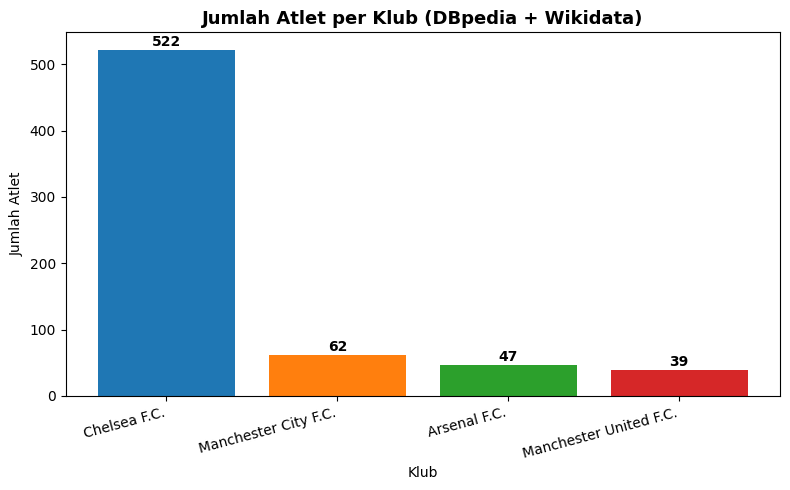

Chart disimpan sebagai distribusi_atlet_per_klub.png


In [8]:
import matplotlib.pyplot as plt

# Bar chart jumlah atlet per klub
club_counts = df_combined.groupby('club')['athlete'].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(club_counts.index, club_counts.values,
              color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Tambahkan label nilai di atas bar
for bar, val in zip(bars, club_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontweight='bold')

ax.set_title('Jumlah Atlet per Klub (DBpedia + Wikidata)', fontsize=13, fontweight='bold')
ax.set_xlabel('Klub')
ax.set_ylabel('Jumlah Atlet')
ax.set_xticklabels(club_counts.index, rotation=15, ha='right')
plt.tight_layout()
plt.savefig('distribusi_atlet_per_klub.png', dpi=150)
plt.show()
print('Chart disimpan sebagai distribusi_atlet_per_klub.png')

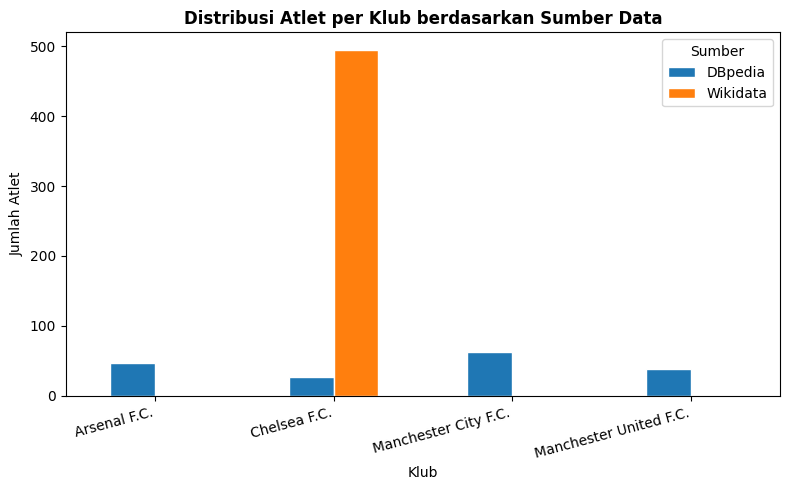

Chart disimpan sebagai distribusi_per_sumber.png


In [9]:
# Stacked bar: distribusi per sumber per klub
pivot = df_combined.groupby(['club', 'source']).size().unstack(fill_value=0)

pivot.plot(kind='bar', figsize=(8, 5), color=['#1f77b4', '#ff7f0e'],
           edgecolor='white')
plt.title('Distribusi Atlet per Klub berdasarkan Sumber Data', fontsize=12, fontweight='bold')
plt.xlabel('Klub')
plt.ylabel('Jumlah Atlet')
plt.xticks(rotation=15, ha='right')
plt.legend(title='Sumber')
plt.tight_layout()
plt.savefig('distribusi_per_sumber.png', dpi=150)
plt.show()
print('Chart disimpan sebagai distribusi_per_sumber.png')

## 💾 Step 6 — Simpan Hasil ke CSV

In [10]:
output_file = 'combined_athlete_club.csv'
df_combined.to_csv(output_file, index=False)
print(f'✅ File berhasil disimpan: {output_file}')
print(f'   Total baris : {len(df_combined)}')
print(f'   Kolom       : {df_combined.columns.tolist()}')
print()
df_combined.head()

✅ File berhasil disimpan: combined_athlete_club.csv
   Total baris : 670
   Kolom       : ['athlete', 'club', 'source']



,athlete,club,source
0,"Lewis Thomas (footballer, born 2002)",Manchester City F.C.,DBpedia
1,Peter Cruse,Arsenal F.C.,DBpedia
2,Johan Guadagno,Manchester United F.C.,DBpedia
3,Joe Norton (footballer),Manchester United F.C.,DBpedia
4,Lakyle Samuel,Manchester City F.C.,DBpedia


In [11]:
# Download file hasil ke komputer lokal
files.download(output_file)
print('📥 File combined_athlete_club.csv sedang didownload...')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 File combined_athlete_club.csv sedang didownload...
